# 5a_QRF_TARGETS

Apply trained QRF model to Antarctic and Greenland target grids.

**Outputs per region** (single pass, all quantiles):

| Variable | Description |
|---|---|
| `qrf_q05/q25/q50/q75/q95_raw` | Raw quantile predictions |
| `qrf_q05/q25/q50/q75/q95_corr` | Spline-corrected (Q50 shift applied) |
| `qrf_iqr50/iqr90_raw/corr` | Inter-quantile ranges |
| `qrf_sigma_raw/corr` | Gaussian-equiv σ from IQR90 |

**Spline correction:** PCHIP spline fitted on calibration Q50. Applied to Q50 only.
Other quantiles shifted by the same additive offset (interval widths preserved).

**Shannon H:** Normalised entropy of Q50 field stored as global dataset attribute.

**Files written:**
- `output/targets/Aq1_5_QRF_v{MODEL_VERSION}.nc` — Antarctica
- `output/targets/Kq1_5_QRF_v{MODEL_VERSION}.nc` — Greenland

> Requires: `output/models/qrf_artefacts.pkl` (written by `4a_QRF_MODEL`)

## 1. Imports & constants

In [1]:
import sys, json, pickle, warnings, datetime

import time

import numpy as np
import pandas as pd
import xarray as xr
from pathlib import Path
from pyproj import Transformer
from scipy.stats import entropy as scipy_entropy
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings('ignore')
sys.path.insert(0, '.')
from config import *
from lib.utils import grid_from_xr_dataset
# 
    # obs_model, q_clip_min, q_clip_max, random_state, q_min, q_max,
    # ant_crs, grl_crs, model_dir, targets_dir, param_paths,
    # netcdf_compression_level, NETCDF_AUTHOR, NETCDF_CONVENTIONS,
    # PRED_QUANTILES, TARGET_GRIDS, MODEL_VERSION,


targets_dir.mkdir(parents=True, exist_ok=True)
QUANTILES = PRED_QUANTILES   # [0.05, 0.25, 0.50, 0.75, 0.95]
Q50_IDX   = QUANTILES.index(0.50)
print(f'quantiles    : {QUANTILES}')
print(f'model version: {MODEL_VERSION}')
print(f'targets_dir  : {targets_dir}')


✓ config.py v4.1 | obs_model: 21 | obs_sweep: 22 | obs: 36 | ensemble: qrf+gbm+sim
quantiles    : [0.05, 0.25, 0.5, 0.75, 0.95]
model version: 0_4
targets_dir  : output/targets


## 2. Helpers

In [2]:
# ── Grid loader ───────────────────────────────────────────────────────────────
def load_grid(grid_cfg, obs_sel):
    label, xcol, ycol = grid_cfg['label'], grid_cfg['x_col'], grid_cfg['y_col']
    df = pd.read_parquet(grid_cfg['parquet'])
    print(f'\n[{label.upper()}] {len(df):,} rows')
    missing = [f for f in obs_sel if f not in df.columns]
    if missing:
        warnings.warn(f'Missing features {missing} — filling NaN')
        for f in missing: df[f] = np.nan
    nan_cols = {f: int(df[f].isna().sum()) for f in obs_sel if df[f].isna().any()}
    if nan_cols: print(f'  NaN counts: {nan_cols}')
    else: print(f'  All {len(obs_sel)} features OK, no NaNs')
    x_vals = np.sort(df[xcol].unique()).astype(np.float64)
    y_vals = np.sort(df[ycol].unique()).astype(np.float64)
    nx, ny = len(x_vals), len(y_vals)
    is_reg = (len(df) == nx * ny)
    if is_reg:
        dx, dy = np.diff(x_vals), np.diff(y_vals)
        print(f'  Regular {ny}x{nx}  dx={dx[0]:.0f}m dy={dy[0]:.0f}m')
    else:
        print(f'  Irregular {len(df):,} pts (expected {ny*nx:,}) — griddata fallback')
    return df, x_vals, y_vals, ny, nx, is_reg

def build_X(df, obs_sel, scaler):
    X_raw  = df[obs_sel].values.astype(np.float32)
    finite = np.isfinite(X_raw).all(axis=1)
    X_sc   = np.full_like(X_raw, np.nan)
    if finite.any():
        X_sc[finite] = scaler.transform(X_raw[finite]).astype(np.float32)
    print(f'  finite points: {finite.sum():,} / {len(df):,}')
    return X_sc, finite

def to_2d(vals_1d, df, x_vals, y_vals, xcol, ycol, is_reg):
    ny, nx = len(y_vals), len(x_vals)
    if is_reg:
        tmp = df[[xcol, ycol]].copy()
        tmp['_v'] = vals_1d
        return tmp.pivot(index=ycol, columns=xcol, values='_v').values.astype(np.float32)
    from scipy.interpolate import griddata
    gx, gy = np.meshgrid(x_vals, y_vals)
    return griddata(df[[xcol, ycol]].values, vals_1d, (gx, gy), method='nearest').astype(np.float32)

def apply_spline(spline, vals):
    out = np.full(vals.shape, np.nan, dtype=np.float32)
    ok  = np.isfinite(vals)
    out[ok] = np.clip(spline(vals[ok]).astype(np.float32), q_clip_min, q_clip_max)
    return out

def shannon_H_norm(values_2d, bin_width=0.010):
    v = values_2d.ravel()
    v = v[np.isfinite(v)]
    if len(v) == 0: return np.nan
    bins = np.arange(q_clip_min, q_clip_max + bin_width, bin_width)
    counts, _ = np.histogram(v, bins=bins)
    p = counts / counts.sum()
    p = p[p > 0]
    H = float(scipy_entropy(p))
    H_max = float(np.log(len(bins) - 1))
    return round(H / H_max, 6) if H_max > 0 else 0.0

def make_ds(arrays, x_vals, y_vals, grid_cfg, params, obs_sel, model_tag, extra=None):
    coords = {'y': y_vals, 'x': x_vals}
    dvars = {name: xr.DataArray(arr, dims=['y','x'], coords=coords,
                                attrs={'units':'W m-2','long_name':name.replace('_',' ')})
             for name, arr in arrays.items()}
    ds = xr.Dataset(dvars, coords=coords)
    attrs = dict(
        title=f'{model_tag} heat-flow prediction',
        model=model_tag, version=MODEL_VERSION,
        institution=NETCDF_AUTHOR, Conventions=NETCDF_CONVENTIONS,
        crs=grid_cfg['crs'], epsg=str(grid_cfg['epsg']),
        region=grid_cfg['label'].upper(),
        created=datetime.datetime.utcnow().isoformat()+'Z',
        obs_sel=json.dumps(obs_sel),
        quantiles=json.dumps(QUANTILES),
        q_clip_min=float(q_clip_min), q_clip_max=float(q_clip_max),
        params_json=json.dumps(params, default=str),
    )
    if extra: attrs.update(extra)
    ds.attrs = attrs
    return ds

def save_nc(ds, path):
    enc = {v: {'zlib':True,'complevel':netcdf_compression_level,'dtype':'float32'}
           for v in ds.data_vars}
    ds.to_netcdf(path, encoding=enc)
    print(f'  Saved {path}  ({path.stat().st_size/1e6:.1f} MB)')

print('Helpers ready.')


Helpers ready.


## 3. Load QRF artefacts

In [3]:
## 3. Load QRF artefacts

with open(model_dir / 'qrf_artefacts.pkl', 'rb') as fp:
    art = pickle.load(fp)

qrf      = art['model']
scaler   = art['scaler']
spline   = art['spline']
obs_sel  = art['obs_sel']
PARAMS   = art['PARAMS']
qhat_qrf = art['qhat_qrf']

print(f'QRF loaded  n_estimators={qrf.n_estimators}  features={len(obs_sel)}')
print(f'obs_sel: {obs_sel}')
print(f'qhat_qrf: {qhat_qrf:.6f}')

QRF loaded  n_estimators=1000  features=5
obs_sel: ['MOHO', 'GEOID', 'REVEAL_P150', 'DEM', 'SEDIMENT']
qhat_qrf: -0.002000


## 4. Predict & write netCDF

Loops over `TARGET_GRIDS` (ant + grl). For each:
1. Load parquet, verify features, check grid regularity
2. Scale features with train-fold scaler
3. Single `qrf.predict(X, quantiles=[...])` call
4. Apply Q50 spline correction, propagate offset to all quantiles
5. Compute IQR50, IQR90, σ
6. Reshape 1D → 2D (y, x)
7. Write compressed netCDF with metadata

In [4]:
art

{'model': RandomForestQuantileRegressor(max_depth=50, max_features=0.7,
                               min_samples_leaf=5, n_estimators=1000, n_jobs=-1,
                               random_state=42),
 'obs_sel': ['MOHO', 'GEOID', 'REVEAL_P150', 'DEM', 'SEDIMENT'],
 'scaler': StandardScaler(),
 'spline': <scipy.interpolate._cubic.PchipInterpolator at 0x32c282a80>,
 'qhat_qrf': -0.0020000003278255463,
 'QUANTILES': [0.05, 0.25, 0.5, 0.75, 0.95],
 'Q_CLIP_MIN': 0.0,
 'q_clip_max': 0.35,
 'CONFORMAL_ALPHA': 0.1,
 'PARAMS': {'model': 'QRF',
  'sweep_notebook': '3a_QRF_SWEEP',
  'best_r2_cal': 0.4929642295624892,
  'n_estimators': 1000,
  'max_depth': 50,
  'min_samples_leaf': 5,
  'max_features': 0.7,
  'use_log_target': False,
  'q_clip_max': 0.2,
  'cal_frac': 0.1,
  'obs_sel': ['MOHO', 'GEOID', 'REVEAL_P150', 'DEM', 'SEDIMENT'],
  'n_sweep_runs': 200}}

In [5]:

results_qrf = {}

for grid_cfg in TARGET_GRIDS:
    label = grid_cfg['label']
    prefix = 'Aq1_5' if label == 'ant' else 'Kq1_5'
    out_path = targets_dir / f'{prefix}_QRF_v{MODEL_VERSION}.nc'

    df, x_vals, y_vals, ny, nx, is_reg = load_grid(grid_cfg, obs_sel)
    X_sc, finite = build_X(df, obs_sel, scaler)
    xcol, ycol = grid_cfg['x_col'], grid_cfg['y_col']

    # ── QRF prediction (single pass, all quantiles) ──────────────────────
    print(f'  Predicting {len(df):,} points × {len(QUANTILES)} quantiles ...')
    t0 = time.time()
    q_preds = np.full((len(df), len(QUANTILES)), np.nan, dtype=np.float32)
    q_preds[finite] = qrf.predict(
        X_sc[finite], quantiles=QUANTILES
    ).astype(np.float32)
    print(f'  QRF predict wall time: {(time.time()-t0)/60:.1f} min')

    # ── clip to physical range ────────────────────────────────────────────
    q_preds = np.clip(q_preds, q_clip_min, q_clip_max)

    # ── spline correction on Q50; offsets for other quantiles ─────────────
    q50_raw  = q_preds[:, Q50_IDX]
    q50_corr = apply_spline(spline, q50_raw)
    offset   = q50_corr - q50_raw                 # additive shift

    arrays = {}
    qnames = ['q05','q25','q50','q75','q95']
    for qi, qn in enumerate(qnames):
        raw_1d  = q_preds[:, qi]
        corr_1d = np.clip(raw_1d + offset, q_clip_min, q_clip_max)
        arrays[f'qrf_{qn}_raw' ] = to_2d(raw_1d,  df, x_vals, y_vals, xcol, ycol, is_reg)
        arrays[f'qrf_{qn}_corr'] = to_2d(corr_1d, df, x_vals, y_vals, xcol, ycol, is_reg)

    # ── derived uncertainty metrics ───────────────────────────────────────
    iqr50_raw  = q_preds[:,3] - q_preds[:,1]          # Q75-Q25
    iqr90_raw  = q_preds[:,4] - q_preds[:,0]          # Q95-Q05
    sigma_raw  = iqr90_raw / (2 * 1.6449)             # Gaussian-equiv sigma
    iqr50_corr = np.clip(iqr50_raw + 0, 0, q_clip_max)  # offsets cancel in IQR
    iqr90_corr = np.clip(iqr90_raw + 0, 0, q_clip_max)
    sigma_corr = iqr90_corr / (2 * 1.6449)

    for name, arr1d in [
        ('qrf_iqr50_raw',  iqr50_raw),  ('qrf_iqr90_raw',  iqr90_raw),
        ('qrf_std_raw',  sigma_raw),
        ('qrf_iqr50_corr', iqr50_corr), ('qrf_iqr90_corr', iqr90_corr),
        ('qrf_std_corr', sigma_corr),
    ]:
        arrays[name] = to_2d(arr1d, df, x_vals, y_vals, xcol, ycol, is_reg)

    # ── Shannon entropy (normalised, scalar attribute) ────────────────────
    H_raw  = shannon_H_norm(arrays['qrf_q50_raw'])
    H_corr = shannon_H_norm(arrays['qrf_q50_corr'])
    print(f'  Shannon H (norm): raw={H_raw:.4f}  corr={H_corr:.4f}')

    # ── build & save dataset ──────────────────────────────────────────────
    ds = make_ds(arrays, x_vals, y_vals, grid_cfg, PARAMS, obs_sel,
                 model_tag=f'{prefix}_QRF',
                 extra={'shannon_H_q50_raw': H_raw,
                        'shannon_H_q50_corr': H_corr,
                        'spline_applied': 'Q50 only; other quantiles shifted by Q50 offset'})
    
    grid_cfg['agrid'] =  grid_from_xr_dataset(ds, name = label)

    save_nc(ds, out_path)
    results_qrf[label] = ds
    print(f'  [{label.upper()}] done.')

print('\nAll QRF target grids complete.')



[ANT] 1,779,556 rows
  NaN counts: {'DEM': 383490}
  Regular 1334x1334  dx=5000m dy=5000m
  finite points: 1,396,066 / 1,779,556
  Predicting 1,779,556 points × 5 quantiles ...
  QRF predict wall time: 34.3 min
  Shannon H (norm): raw=0.3877  corr=0.4793
  Saved output/targets/Aq1_5_QRF_v0_4.nc  (51.2 MB)
  [ANT] done.

[GRL] 172,360 rows
  All 5 features OK, no NaNs
  Regular 556x310  dx=4950m dy=4950m
  finite points: 172,360 / 172,360
  Predicting 172,360 points × 5 quantiles ...
  QRF predict wall time: 0.1 min
  Shannon H (norm): raw=0.4686  corr=0.5201
  Saved output/targets/Kq1_5_QRF_v0_4.nc  (6.4 MB)
  [GRL] done.

All QRF target grids complete.


In [6]:
for grid_cfg in TARGET_GRIDS:
    label = grid_cfg['label']
    df_probe = pd.read_parquet(grid_cfg['parquet'])
    print(f"\n[{label}] parquet: {grid_cfg['parquet']}")
    print(f"  shape: {df_probe.shape}")
    print(f"  columns: {list(df_probe.columns)}")
    present = [f for f in obs_sel if f in df_probe.columns]
    missing = [f for f in obs_sel if f not in df_probe.columns]
    print(f"  present ({len(present)}): {present}")
    print(f"  MISSING ({len(missing)}): {missing}")
    if present:
        finite_cnt = df_probe[present].notna().sum()
        print(f"  finite counts (present cols):\n{finite_cnt}")


[ant] parquet: data/antarctica.parquet
  shape: (1779556, 39)
  columns: ['lon', 'lat', 'x', 'y', 'MOHO_GRAV', 'MOHO_GRAV_U', 'MOHO', 'MOHO_U', 'LAB', 'CTD', 'EMAG2_LOG', 'FREE_AIR', 'BOUGUER', 'SI', 'GEOID', 'REVEAL_S60', 'REVEAL_S70', 'REVEAL_S80', 'REVEAL_S90', 'REVEAL_S100', 'REVEAL_S140', 'REVEAL_S200', 'REVEAL_P50', 'REVEAL_P60', 'REVEAL_P90', 'REVEAL_P150', 'LITH_RHO', 'CRUST_RHO', 'GLiM', 'TC1', 'GPRV', 'REG', 'DEM', 'SEDIMENT', 'MAG_SEIS_MOHO', 'REVEAL_VP60VS70', 'REVEAL_VP90VS60', 'REVEAL_VP50VS80', 'VOLC_DIST']
  present (5): ['MOHO', 'GEOID', 'REVEAL_P150', 'DEM', 'SEDIMENT']
  MISSING (0): []
  finite counts (present cols):
MOHO           1779556
GEOID          1779556
REVEAL_P150    1779556
DEM            1396066
SEDIMENT       1779556
dtype: int64

[grl] parquet: data/greenland.parquet
  shape: (172360, 39)
  columns: ['lon', 'lat', 'x', 'y', 'MOHO_GRAV', 'MOHO_GRAV_U', 'MOHO', 'MOHO_U', 'LAB', 'CTD', 'EMAG2_LOG', 'FREE_AIR', 'BOUGUER', 'SI', 'GEOID', 'REVEAL_S60', 'REV

## 5. Summary statistics

In [7]:
for label, ds in results_qrf.items():
    print(f'\n[{label.upper()}] variables:')
    for v in ds.data_vars:
        arr = ds[v].values
        fin = arr[np.isfinite(arr)]
        print(f'  {v:30s}  mean={fin.mean()*1e3:.1f}  '
              f'std={fin.std()*1e3:.1f}  '
              f'[{fin.min()*1e3:.1f}, {fin.max()*1e3:.1f}] mW/m2')



[ANT] variables:
  qrf_q05_raw                     mean=24.3  std=7.9  [1.0, 56.0] mW/m2
  qrf_q05_corr                    mean=23.4  std=10.2  [1.0, 339.0] mW/m2
  qrf_q25_raw                     mean=44.1  std=7.6  [8.0, 79.5] mW/m2
  qrf_q25_corr                    mean=43.0  std=11.4  [1.0, 342.0] mW/m2
  qrf_q50_raw                     mean=59.4  std=9.1  [17.0, 140.0] mW/m2
  qrf_q50_corr                    mean=58.3  std=13.5  [1.0, 350.0] mW/m2
  qrf_q75_raw                     mean=79.5  std=15.8  [29.3, 350.0] mW/m2
  qrf_q75_corr                    mean=78.5  std=19.6  [12.0, 350.0] mW/m2
  qrf_q95_raw                     mean=146.4  std=58.4  [52.4, 350.0] mW/m2
  qrf_q95_corr                    mean=145.2  std=60.0  [36.0, 350.0] mW/m2
  qrf_iqr50_raw                   mean=35.5  std=13.8  [4.0, 281.0] mW/m2
  qrf_iqr90_raw                   mean=122.0  std=60.1  [21.4, 344.0] mW/m2
  qrf_std_raw                     mean=37.1  std=18.3  [6.5, 104.6] mW/m2
  qrf_iqr50_corr

In [8]:
grid_cfg['agrid'] =  grid_from_xr_dataset(ds, name = label)

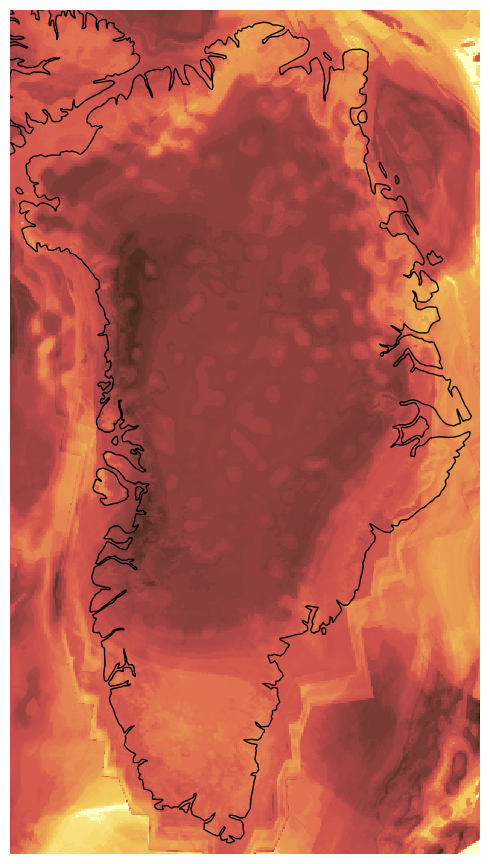

(<Figure size 500x898.058 with 1 Axes>, <GeoAxes: >)

In [9]:
TARGET_GRIDS[1]['agrid'].map('qrf_q50_corr', cmap = hf_cmap, vmin = q_min, vmax = q_max)

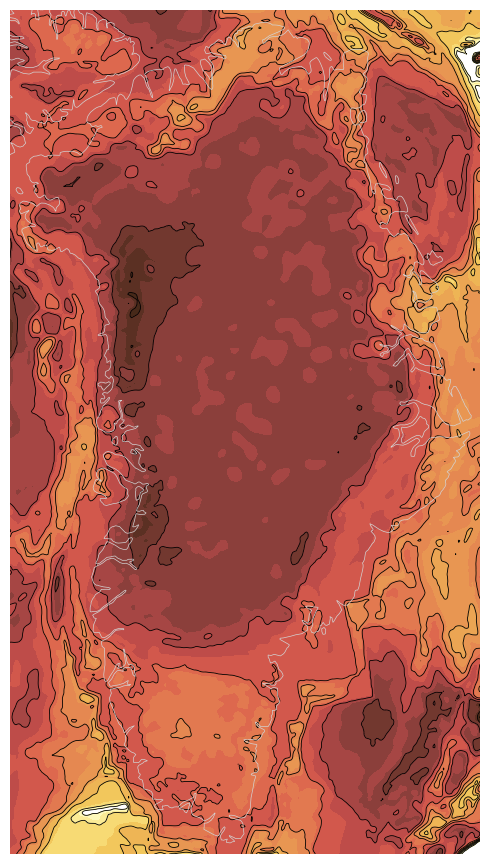

(<Figure size 500x898.058 with 1 Axes>, <GeoAxes: >)

In [10]:
TARGET_GRIDS[1]['agrid'].contour_map('qrf_q50_corr', cmap = hf_cmap, vmin = q_min, vmax = q_max, 
                                     n_contour_fills= 20, n_contors = 20, 
                                     smooth=True,
                                     smooth_kernel_size=1)

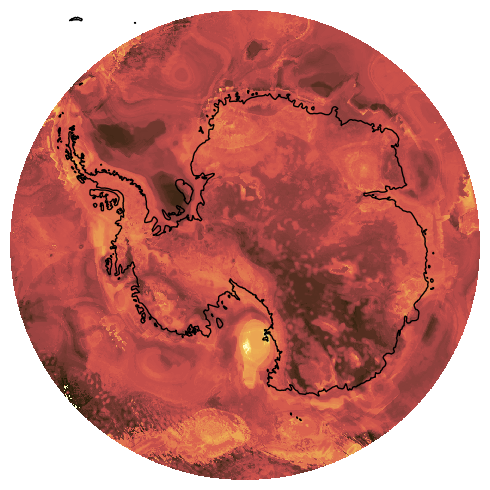

(<Figure size 500x500 with 1 Axes>, <GeoAxes: >)

In [11]:
TARGET_GRIDS[0]['agrid'].map('qrf_q50_corr', cmap = hf_cmap, vmin = q_min, vmax = q_max)

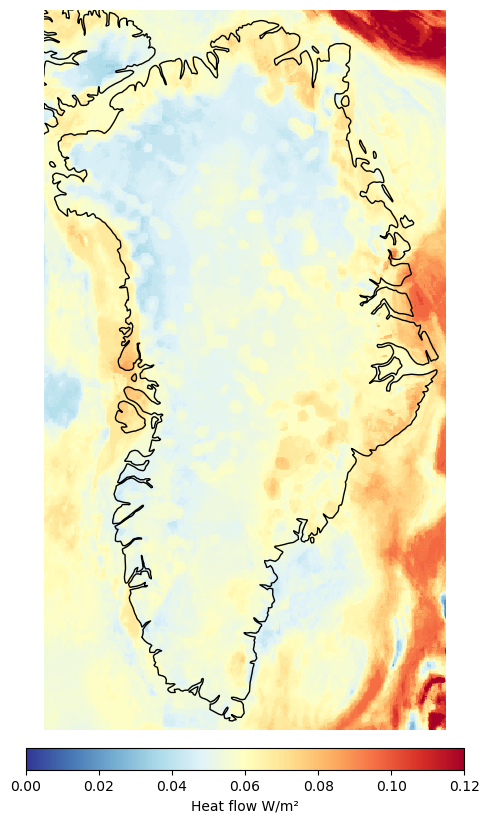

In [ ]:


fig, ax = ant_qrf.map(
    'qrf_q50_corr',
    cmap        = hf_cmap,
    vmin        = q_min,
    vmax        = q_max,
    cbar        = True,
    cbar_title  = 'Heat flow',
    cbar_units_label = 'W/m²',
    coastlines  = True,
    show        = True,
    return_fig  = True,
)
#results_qrf['grl']['qrf_q50_corr'].plot(vmin = q_min, vmax = 0.12)